In [1]:
import os
from pathlib import Path
from scipy.ndimage import gaussian_filter1d

import numpy as np
import pandas as pd
import scipy.io as sio
import matplotlib.pyplot as plt

from IPython.display import display

In [2]:
os.chdir("/home/ganchao")

folderpath = Path("isilon/AllStaff/auditory/m96z")
# out_dir = Path("data/m96z_U331_phee_ant")
out_dir = Path("/home/ganchao/isilon/AllStaff/DCF/data/m96z_U331_phee_ant")
out_dir.mkdir(parents=True, exist_ok=True)

u_id = "U331"
target_call_type = "phee"
target_vocfile = "ant_m96z_S14_000001.txt"

mua_path = folderpath / f"m96z_{u_id}_playback_mua.mat"

In [3]:
def load_pbdata(path):
    mat = sio.loadmat(
        path,
        squeeze_me=True,
        struct_as_record=False,
        simplify_cells=True,
    )
    return mat["pbdata"]

pbdata = load_pbdata(mua_path)
call_block = pbdata[target_call_type]

In [4]:
vocfiles = np.array(call_block["vocfiles"]).astype(str)
stim_idx = np.where(vocfiles == target_vocfile)[0][0]

sample_rate = float(pbdata["sample_rate"])
prestim = float(pbdata["prestim"])
poststim = float(pbdata["poststim"])
duration_ms = float(call_block["duration"][stim_idx])

print("u_id:", u_id)
print("stim_idx:", stim_idx)
print("vocfile:", target_vocfile)
print("sample_rate:", sample_rate)
print("prestim:", prestim)
print("poststim:", poststim)
print("duration_ms:", duration_ms)

u_id: U331
stim_idx: 0
vocfile: ant_m96z_S14_000001.txt
sample_rate: 1220.703125
prestim: 500.0
poststim: 500.0
duration_ms: 1806.0


In [5]:
channel_arrays = []

for ch_idx, ch_data in enumerate(call_block["mua"]):
    arr = np.asarray(ch_data[stim_idx], dtype=np.float32)

    if arr.ndim == 1:
        arr = arr[None, :]

    channel_arrays.append(arr)

n_trials = min(arr.shape[0] for arr in channel_arrays)
n_T = min(arr.shape[1] for arr in channel_arrays)
n_neuron = len(channel_arrays)

X = np.stack(
    [arr[:n_trials, :n_T] for arr in channel_arrays],
    axis=0,
)  # [n_neuron, n_trial, T]

X = np.transpose(X, (1, 2, 0))  # [n_trial, T, n_neuron]

time_ms = np.arange(n_T) / sample_rate * 1000.0 - prestim

print("X shape [n_trial, T, n_neuron]:", X.shape)

X shape [n_trial, T, n_neuron]: (5, 3426, 32)


In [6]:
# Simple MUA preprocessing for DCF fitting
# raw X shape: [n_trial, T, n_channel]

X_raw = X.astype(np.float32).copy()
X_raw = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)

# 1. remove dead / nearly constant channels
ch_std_raw = X_raw.std(axis=(0, 1))
good_ch = ch_std_raw > 1e-8

X_raw_good = X_raw[:, :, good_ch]
print("kept channels:", good_ch.sum(), "/", good_ch.size)

# 2. per-trial pre-stimulus baseline subtraction
pre_stim_mask = time_ms < 0

if pre_stim_mask.sum() < 3:
    raise ValueError("Too few pre-stimulus bins. Check time_ms.")

baseline_mean = X_raw_good[:, pre_stim_mask, :].mean(axis=1, keepdims=True)
X_base = X_raw_good - baseline_mean

# 3. mild Gaussian temporal smoothing
# dt ≈ 0.819 ms, sigma=1 bin is mild.
SMOOTH_SIGMA = 5.0

X_smooth = gaussian_filter1d(
    X_base,
    sigma=SMOOTH_SIGMA,
    axis=1,
    mode="nearest",
)

# 4. per-channel standardization after smoothing
# Use full-trial std for stability.
channel_std = X_smooth.std(axis=(0, 1), keepdims=True) + 1e-8
X_proc = (X_smooth / channel_std).astype(np.float32)

trial_list_proc = [X_proc[i] for i in range(X_proc.shape[0])]

print("X_proc shape:", X_proc.shape)
print("mean/std:", X_proc.mean(), X_proc.std())
print("min/max:", X_proc.min(), X_proc.max())

kept channels: 30 / 32
X_proc shape: (5, 3426, 30)
mean/std: 0.077151515 1.0066974
min/max: -5.557713 12.538121


In [7]:
# Trim initial transient artifact
TRIM_START = 20

X_proc_trim = X_proc[:, TRIM_START:, :]
X_raw_good_trim = X_raw_good[:, TRIM_START:, :]
time_ms_trim = time_ms[TRIM_START:]

print("trim start bins:", TRIM_START)
print("trim start ms:", time_ms[TRIM_START])
print("X_proc_trim shape:", X_proc_trim.shape)

trim start bins: 20
trim start ms: -483.616
X_proc_trim shape: (5, 3406, 30)


In [8]:
trial_list = [X_proc_trim[i] for i in range(X_proc_trim.shape[0])]
n_neuron_proc = X_proc_trim.shape[2]

print("n_trial:", len(trial_list))
print("one trial shape [T, n_neuron]:", trial_list[0].shape)

n_trial: 5
one trial shape [T, n_neuron]: (3406, 30)


In [9]:
head_df = pd.DataFrame(
    trial_list[0][:10, :8],
    columns=[f"ch_{i}" for i in range(8)]
)

head_df.insert(0, "time_ms", time_ms_trim[:10])
display(head_df)

,time_ms,ch_0,ch_1,ch_2,ch_3,ch_4,ch_5,ch_6,ch_7
0,-483.6160,1.386748,1.051790,-0.227004,0.761435,1.026234,-0.048581,0.797143,3.403612
1,-482.7968,1.198790,0.938390,-0.418275,0.705429,0.868801,-0.279951,0.740713,3.454254
2,-481.9776,1.029235,0.825755,-0.564488,0.724057,0.710094,-0.448229,0.645034,3.457900
3,-481.1584,0.875279,0.715037,-0.670324,0.802215,0.554999,-0.556217,0.507723,3.410855
4,-480.3392,0.733139,0.608933,-0.742507,0.920455,0.409032,-0.611209,0.329852,3.313574
5,-479.5200,0.599711,0.511919,-0.787013,1.058628,0.278767,-0.622273,0.117250,3.170941
6,-478.7008,0.474175,0.429797,-0.806867,1.199248,0.171810,-0.598061,-0.119218,2.991634
7,-477.8816,0.357852,0.368953,-0.801450,1.329856,0.095766,-0.545685,-0.364418,2.786988
8,-477.0624,0.253997,0.334757,-0.767097,1.443652,0.056457,-0.469683,-0.600693,2.570207
9,-476.2432,0.167132,0.330932,-0.699101,1.538902,0.056609,-0.372547,-0.809886,2.354796


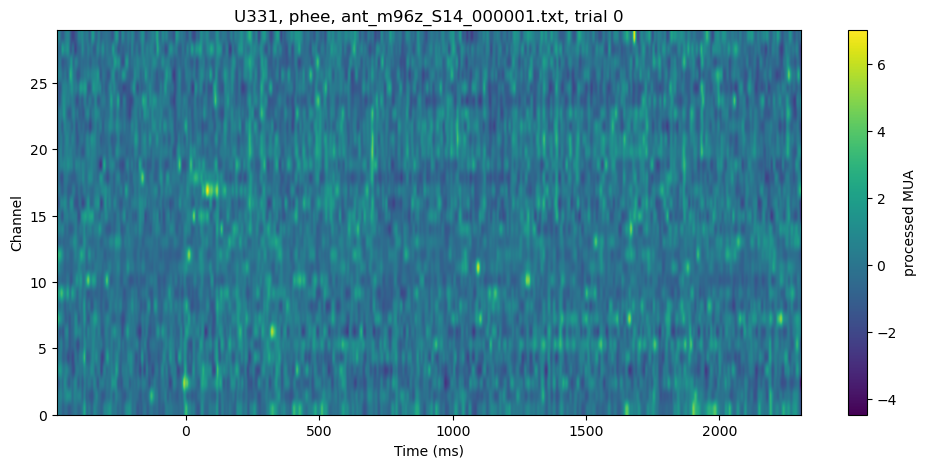

In [10]:
plt.figure(figsize=(12, 5))
plt.imshow(
    # trial_list[0].T,
    X_proc_trim[0].T,
    aspect="auto",
    origin="lower",
    # extent=[time_ms[0], time_ms[-1], 0, n_neuron - 1],
    extent=[time_ms_trim[0], time_ms_trim[-1], 0, n_neuron_proc - 1],
)
plt.xlabel("Time (ms)")
plt.ylabel("Channel")
plt.title(f"{u_id}, {target_call_type}, {target_vocfile}, trial 0")
plt.colorbar(label="processed MUA")
plt.show()

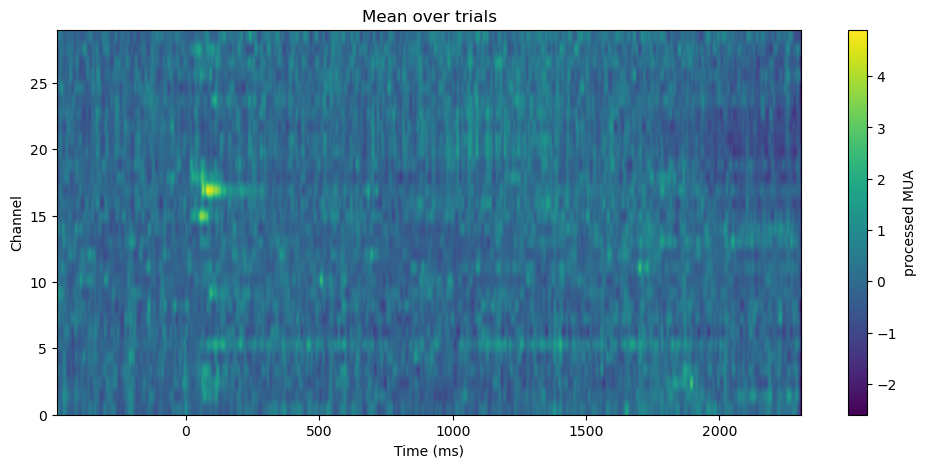

In [11]:
# mean_trial = X.mean(axis=0)  # [T, n_neuron]
mean_trial = X_proc_trim.mean(axis=0)

plt.figure(figsize=(12, 5))
plt.imshow(
    mean_trial.T,
    aspect="auto",
    origin="lower",
    # extent=[time_ms[0], time_ms[-1], 0, n_neuron - 1],
    extent=[time_ms_trim[0], time_ms_trim[-1], 0, n_neuron_proc - 1],
)
plt.xlabel("Time (ms)")
plt.ylabel("Channel")
plt.title("Mean over trials")
plt.colorbar(label="processed MUA")
plt.show()

In [12]:
# channel_mean = X.mean(axis=(0, 1), keepdims=True)
# channel_std = X.std(axis=(0, 1), keepdims=True) + 1e-8

# X_z = (X - channel_mean) / channel_std
# trial_list_z = [X_z[i] for i in range(X_z.shape[0])]

# print("X_z shape:", X_z.shape)
# print("mean:", X_z.mean())
# print("std:", X_z.std())

In [13]:
np.savez(
    out_dir / "dataset_samples.npz",
    # samples=X_z.astype(np.float32),
    samples=X_proc_trim.astype(np.float32),
)

np.savez(
    out_dir / "dataset_samples_raw.npz",
    # samples=X.astype(np.float32),
    samples=X_raw_good_trim.astype(np.float32),
)


meta = {
    "u_id": u_id,
    "call_type": target_call_type,
    "vocfile": target_vocfile,
    "stim_idx": int(stim_idx),

    "sample_rate": float(sample_rate),
    "prestim": float(prestim),
    "poststim": float(poststim),
    "duration_ms": float(duration_ms),
    "time_ms": time_ms_trim.astype(np.float32),
    "original_time_ms": time_ms.astype(np.float32),
    "trim_start_bins": int(TRIM_START),
    "trim_start_ms": float(time_ms[TRIM_START]),

    "format": "[n_trial, T, n_channel]",
    "raw_shape": X.shape,
    "raw_filtered_shape": X_raw_good_trim.shape,
    "processed_shape": X_proc_trim.shape,
    "untrimmed_processed_shape": X_proc.shape,

    "good_ch": good_ch,
    "kept_channel_idx": np.where(good_ch)[0],
    "removed_channel_idx": np.where(~good_ch)[0],

    "preprocessing": (
        "nan_to_num + bad_channel_filter + "
        "per_trial_prestim_baseline_subtract + "
        "gaussian_temporal_smoothing + "
        "per_channel_std_scale"
    ),

    "bad_channel_threshold_std": 1e-8,
    "baseline_window_ms": [
        float(time_ms[pre_stim_mask].min()),
        float(time_ms[pre_stim_mask].max()),
    ],
    "smooth_sigma_bins": float(SMOOTH_SIGMA),
    "smooth_sigma_ms": float(SMOOTH_SIGMA * np.median(np.diff(time_ms))),

    "baseline_mean": baseline_mean.astype(np.float32),
    "channel_std": channel_std.squeeze().astype(np.float32),
}


np.save(out_dir / "metadata.npy", meta, allow_pickle=True)

print("saved to:", out_dir)

saved to: /home/ganchao/isilon/AllStaff/DCF/data/m96z_U331_phee_ant


In [14]:
saved = np.load(out_dir / "dataset_samples.npz", allow_pickle=True)["samples"]
print(saved.shape)
print(saved.mean(), saved.std(), saved.min(), saved.max())

(5, 3406, 30)
0.08173661 1.0011696 -4.6742973 12.538121


In [15]:
print("X_proc_trim shape:", X_proc_trim.shape)
print("time_ms_trim shape:", time_ms_trim.shape)
print("first saved time:", time_ms_trim[0])
print("last saved time:", time_ms_trim[-1])

X_proc_trim shape: (5, 3406, 30)
time_ms_trim shape: (3406,)
first saved time: -483.616
last saved time: 2305.7599999999998


In [16]:
# # Check whether the first few remaining time bins are still abnormal
# # This diagnostic uses ONLY the trimmed data.

# N_HEAD = 100
# X_check = X_proc_trim
# time_check = time_ms_trim

# N_HEAD = min(N_HEAD, X_check.shape[1] // 2)

# mean_abs_t = np.mean(np.abs(X_check), axis=(0, 2))
# max_abs_t = np.max(np.abs(X_check), axis=(0, 2))
# rms_t = np.sqrt(np.mean(X_check ** 2, axis=(0, 2)))

# def robust_z(x, ref):
#     med = np.median(ref)
#     mad = np.median(np.abs(ref - med))
#     scale = 1.4826 * mad + 1e-8
#     return (x - med) / scale

# rest = slice(N_HEAD, None)

# mean_abs_z = robust_z(mean_abs_t[:N_HEAD], mean_abs_t[rest])
# rms_z = robust_z(rms_t[:N_HEAD], rms_t[rest])

# print("first time after trim:", time_check[0])
# print("head mean |x| / rest median:", mean_abs_t[:N_HEAD].mean() / np.median(mean_abs_t[rest]))
# print("head RMS / rest median:", rms_t[:N_HEAD].mean() / np.median(rms_t[rest]))
# print("max robust z in first window, mean |x|:", np.max(mean_abs_z))
# print("max robust z in first window, RMS:", np.max(rms_z))

# fig, axes = plt.subplots(3, 1, figsize=(9, 6), sharex=True, constrained_layout=True)

# axes[0].plot(time_check, mean_abs_t)
# axes[0].axvspan(time_check[0], time_check[N_HEAD - 1], alpha=0.2)
# axes[0].set_ylabel("mean |x|")

# axes[1].plot(time_check, max_abs_t)
# axes[1].axvspan(time_check[0], time_check[N_HEAD - 1], alpha=0.2)
# axes[1].set_ylabel("max |x|")

# axes[2].plot(time_check, rms_t)
# axes[2].axvspan(time_check[0], time_check[N_HEAD - 1], alpha=0.2)
# axes[2].set_ylabel("RMS")
# axes[2].set_xlabel("time (ms)")

# fig.suptitle("Post-trim initial time-bin diagnostic")
# plt.show()

In [17]:
# # Visualize first few remaining time bins for each trial
# # This diagnostic uses ONLY the trimmed data.

# TRIALS_TO_SHOW = min(5, X_proc_trim.shape[0])
# N_HEAD = min(100, X_proc_trim.shape[1])

# vmax = np.percentile(np.abs(X_proc_trim[:, :N_HEAD, :]), 99)

# fig, axes = plt.subplots(
#     TRIALS_TO_SHOW,
#     1,
#     figsize=(9, 2.0 * TRIALS_TO_SHOW),
#     sharex=True,
#     constrained_layout=True,
# )

# axes = np.atleast_1d(axes)

# for i in range(TRIALS_TO_SHOW):
#     im = axes[i].imshow(
#         X_proc_trim[i, :N_HEAD, :].T,
#         aspect="auto",
#         origin="lower",
#         extent=[time_ms_trim[0], time_ms_trim[N_HEAD - 1], 0, X_proc_trim.shape[2] - 1],
#         cmap="seismic",
#         vmin=-vmax,
#         vmax=vmax,
#     )
#     axes[i].set_ylabel("channel")
#     axes[i].set_title(f"trial {i}, first {N_HEAD} bins after trim")

# axes[-1].set_xlabel("time (ms)")
# fig.colorbar(im, ax=axes, label="processed MUA")
# plt.show()